In [1]:
# Asegúrate de importar los módulos necesarios
import utils
import representation
from dataset import MusicDataset # Asume que el código que compartiste está en 'dataset.py'

import pathlib

In [2]:
DATASET_KEY = "lmd"
BASE_DIR = pathlib.Path(f"./data/{DATASET_KEY}/processed")

names_file = BASE_DIR / "names.txt"
data_directory = BASE_DIR / "notes"

try:
    encoding = representation.load_encoding("./encoding.json")
except FileNotFoundError:
    print(f"ERROR: No se encontró el archivo de encoding en {'./encoding.json'}")

In [23]:
MAX_SEQ_LEN = 10000 #Realmente 1024 en verdad   
MAX_BEAT = 256
USE_CSV = False 
USE_AUGMENTATION = True

# --- Rutas de nombres separadas ---
train_names_file = BASE_DIR / "train-names.txt"
val_names_file = BASE_DIR / "valid-names.txt"
test_names_file = BASE_DIR / "test-names.txt"

# --- Crear Datasets separados ---
# 1. Dataset de Entrenamiento (con data augmentation)
train_dataset = MusicDataset(
    filename=train_names_file,
    data_dir=data_directory,
    encoding=encoding,
    max_seq_len=MAX_SEQ_LEN,
    max_beat=MAX_BEAT,
    use_augmentation=True, # Típicamente SÍ para el entrenamiento
    # ... otros parámetros
)

# 2. Dataset de Validación (sin data augmentation)
valid_dataset = MusicDataset(
    filename=val_names_file,
    data_dir=data_directory,
    encoding=encoding,
    max_seq_len=MAX_SEQ_LEN,
    max_beat=MAX_BEAT,
    use_augmentation=False, # Típicamente NO para validación/prueba
    # ... otros parámetros
)

# 3. Dataset de Prueba (sin data augmentation)
test_dataset = MusicDataset(
    filename=test_names_file,
    data_dir=data_directory,
    encoding=encoding,
    max_seq_len=MAX_SEQ_LEN,
    max_beat=MAX_BEAT,
    use_augmentation=False,
    # ... otros parámetros
)

In [24]:
train_dataset[0]

{'name': '0/00081fefb9485dc2ef642cc300390813',
 'seq': array([[  0,   0,   0,   0,   0,   0],
        [  1,   0,   0,   0,   0,   1],
        [  1,   0,   0,   0,   0,  21],
        ...,
        [  3, 256,   7,  84,  12,  40],
        [  3, 256,  10,  41,   3,   1],
        [  4,   0,   0,   0,   0,   0]], shape=(2005, 6))}

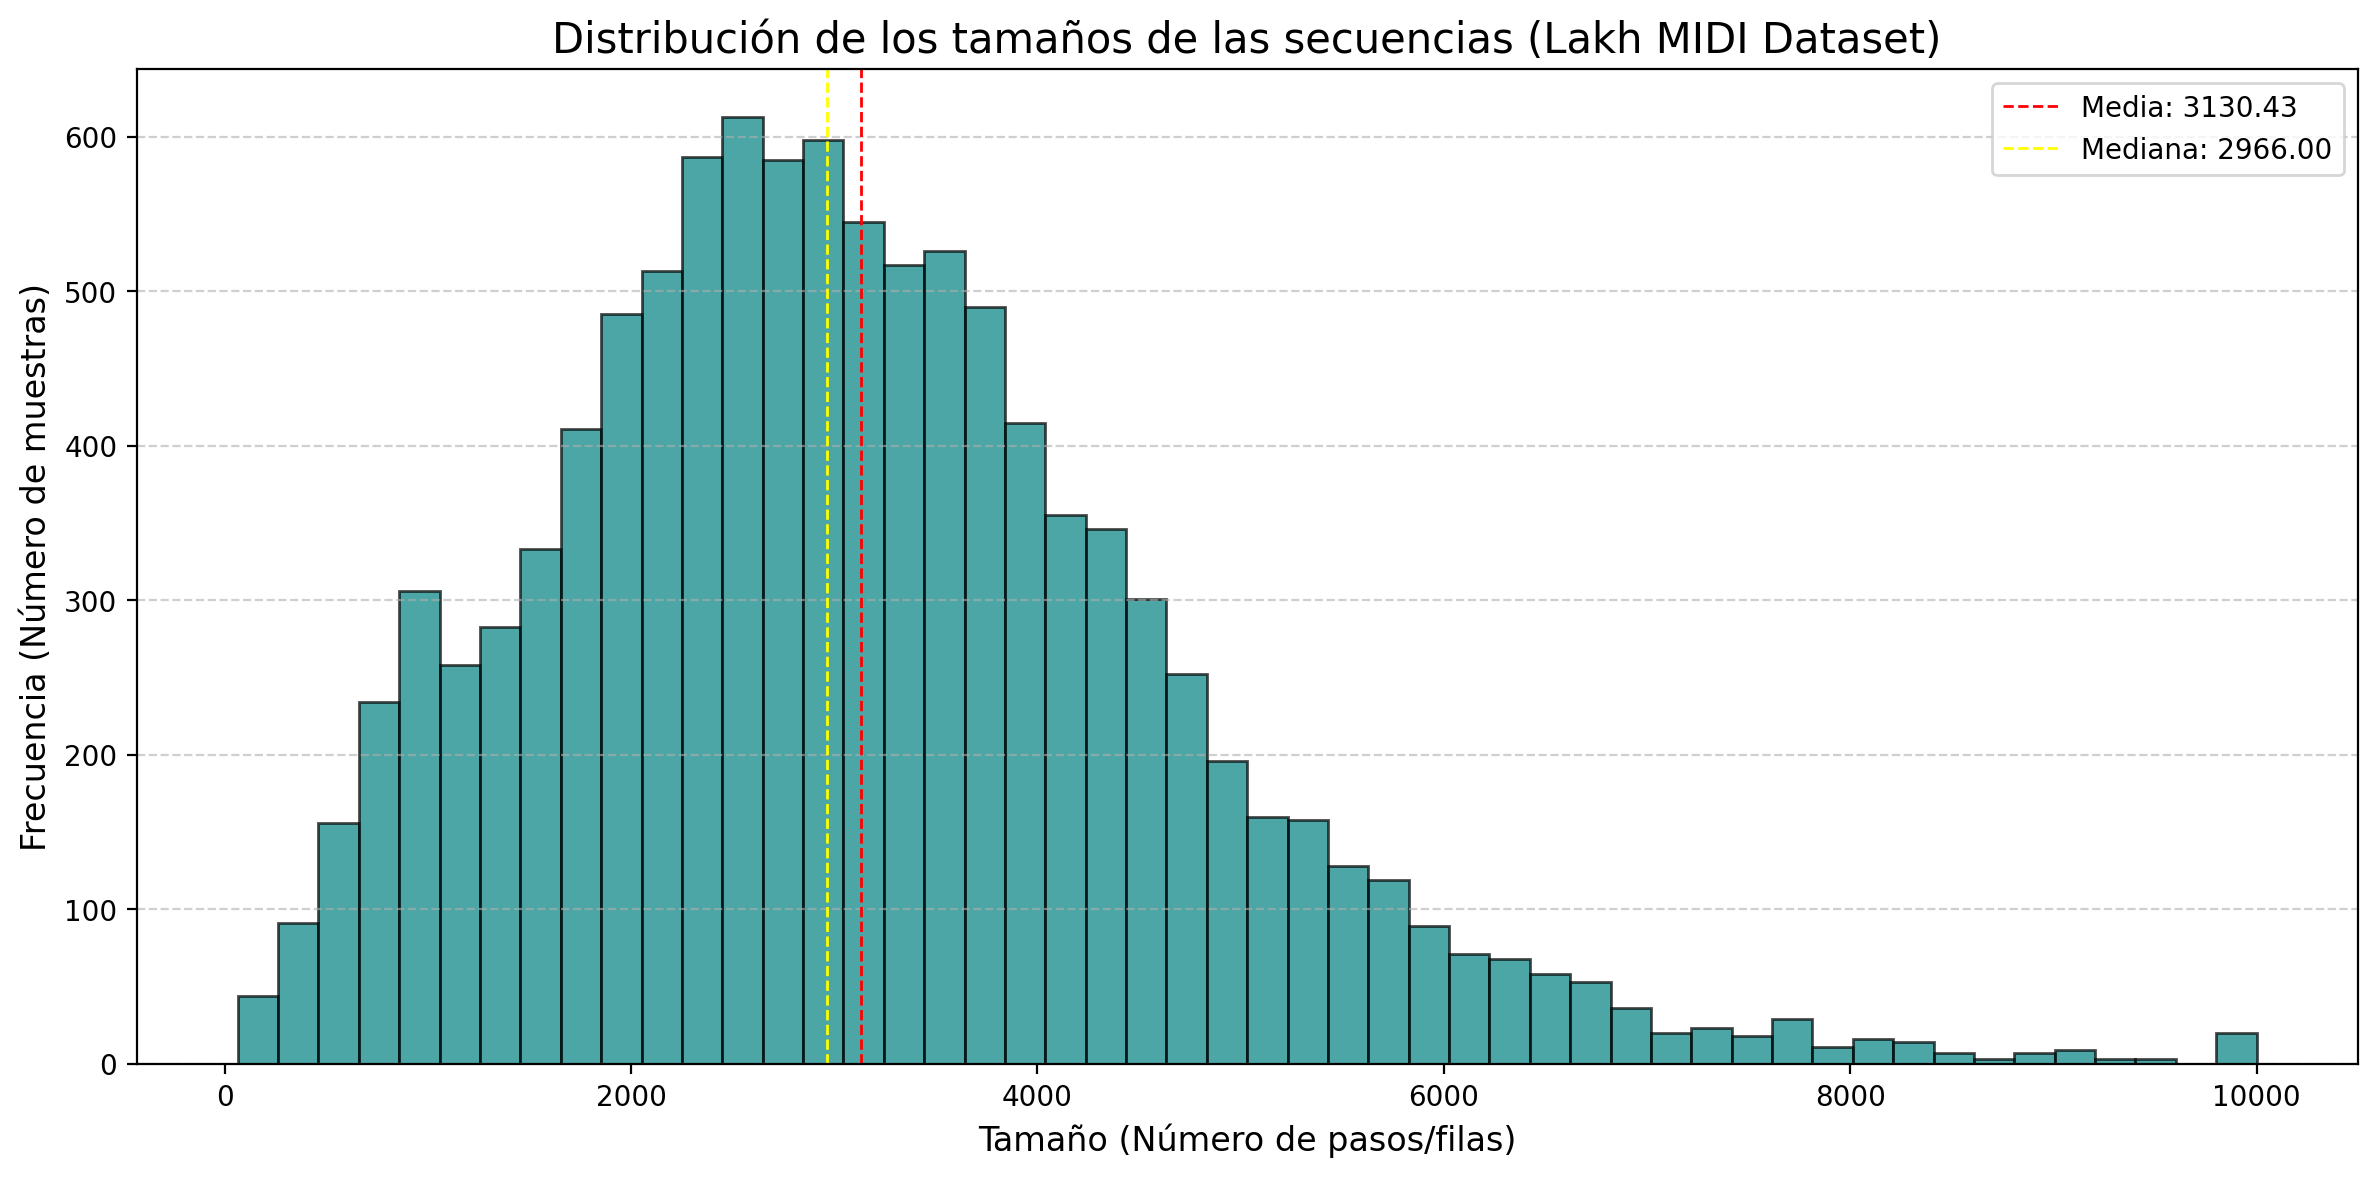

In [26]:
import matplotlib.pyplot as plt

# 1. Extraer los tamaños (shape[0]) de cada elemento en el dataset
# Usamos una lista por comprensión para iterar sobre todo el dataset
sizes = [item['seq'].shape[0] for item in train_dataset]

# 2. Configurar y crear el histograma
plt.figure(figsize=(12, 6))
plt.hist(sizes, bins=50, color='teal', edgecolor='black', alpha=0.7)

# 3. Personalización del gráfico
plt.title('Distribución de los tamaños de las secuencias (Lakh MIDI Dataset)', fontsize=15)
plt.xlabel('Tamaño (Número de pasos/filas)', fontsize=12)
plt.ylabel('Frecuencia (Número de muestras)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 4. Mostrar estadísticas básicas (opcional pero útil)
import numpy as np
plt.axvline(np.mean(sizes), color='red', linestyle='dashed', linewidth=1, label=f'Media: {np.mean(sizes):.2f}')
plt.axvline(np.median(sizes), color='yellow', linestyle='dashed', linewidth=1, label=f'Mediana: {np.median(sizes):.2f}')
plt.legend()

plt.tight_layout()
plt.show()

## DataLoader

In [11]:
import torch
import tqdm

# --- 3. Crear DataLoader ---

BATCH_SIZE = 8
NUM_JOBS = 4 # Número de procesos para cargar los datos

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=MusicDataset.collate
)
valid_loader = torch.utils.data.DataLoader(
    valid_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=MusicDataset.collate
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=MusicDataset.collate
)

# --- 4. Iterar y Ver un Batch (Ejemplo) ---

# Itera sobre el loader para cargar el primer batch y ver su estructura
# for i, batch in enumerate(tqdm.tqdm(train_loader)):
#     print("\nPrimer batch cargado con éxito:")
#     for key, value in batch.items():
#         if key == "name":
#             print(f"  {key}: {len(value)} nombres, ejemplo: {value[0]}")
#         else:
#             print(f"  {key} (Tensor): Shape {value.shape}, Dtype {value.dtype}")
#     break # Detenerse después del primer batch

In [29]:
%run representation.py  # Prueba para main

================= Maps =================
----------------------------------------
instrument_code_map:
{ 'accordion': 15,
  'alto-saxophone': 42,
  'bag-pipe': 61,
  'bandoneon': 17,
  'banjo': 57,
  'baritone-saxophone': 44,
  'bass': 21,
  'bassoon': 47,
  'brasses': 39,
  'celesta': 5,
  'cello': 27,
  'church-organ': 14,
  'clarinet': 48,
  'clavinet': 4,
  'contrabass': 28,
  'dulcimer': 12,
  'electric-bass': 22,
  'electric-guitar': 20,
  'electric-piano': 2,
  'english-horn': 46,
  'flute': 50,
  'glockenspiel': 6,
  'harmonica': 16,
  'harp': 29,
  'harpsichord': 3,
  'horn': 38,
  'kalimba': 60,
  'koto': 59,
  'lead': 54,
  'marimba': 9,
  'melodic-tom': 63,
  'music-box': 7,
  'null': 0,
  'nylon-string-guitar': 18,
  'oboe': 45,
  'ocarina': 53,
  'orchestra-hit': 34,
  'organ': 13,
  'pad': 55,
  'pan-flute': 52,
  'piano': 1,
  'piccolo': 49,
  'recorder': 51,
  'shamisen': 58,
  'shehnai': 62,
  'sitar': 56,
  'slap-bass': 23,
  'soprano-saxophone': 41,
  'steel-string-